# Prototipos de Modelos
## GSHS El Salvador 2013 - Experimentacion Interactiva

Este notebook permite experimentar de forma interactiva con los modelos del pipeline,
sin necesidad de ejecutar el ciclo completo via Makefile.

**Contenido:**
1. Carga de datos procesados
2. Prototipo rapido de regresion (IMC)
3. Prototipo rapido de clasificacion (Riesgo Salud Mental)
4. Comparativa de features Q vs QN
5. Analisis de umbral optimo

In [13]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from src.pipeline_factory import (
    build_preprocessor,
    build_regression_pipeline,
    build_classification_pipeline,
)
from src.features.engineering import (
    get_feature_cols,
    Q_FEATURE_COLS,
    QN_FEATURE_COLS,
    load_codebook,
    feature_names_readable,
)
from src.evaluation.metrics import (
    evaluate_regression,
    evaluate_classification,
    find_optimal_threshold,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = '../data/processed'
codebook = load_codebook('../data/codebook.json')
print('Imports listos.')

Imports listos.


---
## 1. Carga de Datos Procesados

In [14]:
X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_val   = pd.read_csv(f'{DATA_DIR}/X_val.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test.csv')

y_reg_train = pd.read_csv(f'{DATA_DIR}/y_reg_train.csv').squeeze()
y_reg_val   = pd.read_csv(f'{DATA_DIR}/y_reg_val.csv').squeeze()
y_reg_test  = pd.read_csv(f'{DATA_DIR}/y_reg_test.csv').squeeze()

y_clf_train = pd.read_csv(f'{DATA_DIR}/y_clf_train.csv').squeeze()
y_clf_val   = pd.read_csv(f'{DATA_DIR}/y_clf_val.csv').squeeze()
y_clf_test  = pd.read_csv(f'{DATA_DIR}/y_clf_test.csv').squeeze()

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Columnas disponibles: {list(X_train.columns[:5])} ... ({X_train.shape[1]} total)')

Train: (1340, 43) | Val: (383, 43) | Test: (192, 43)
Columnas disponibles: ['QN6', 'QN7', 'QN8', 'QN9', 'QN10'] ... (43 total)


---
## 2. Prototipo Regresion (IMC)

Entrenamiento rapido de LinearRegression y RandomForest para comparar baseline vs ensamble.

In [15]:
FEATURE_TYPE = 'QN'  # Cambiar a 'Q' para experimentar con variables ordinales

# Filtrar columnas segun feature type
feat_cols = get_feature_cols(FEATURE_TYPE)
available = [c for c in feat_cols if c in X_train.columns]
print(f'Features {FEATURE_TYPE}: {len(available)} columnas')

# LinearRegression
lr_pipe = build_regression_pipeline(feature_type=FEATURE_TYPE, model='lr')
lr_pipe.fit(X_train[available], y_reg_train)
lr_metrics = evaluate_regression(lr_pipe, X_val[available], y_reg_val)

# RandomForest (sin SearchCV para rapidez)
rf_pipe = build_regression_pipeline(feature_type=FEATURE_TYPE, model='rf')
rf_pipe.fit(X_train[available], y_reg_train)
rf_metrics = evaluate_regression(rf_pipe, X_val[available], y_reg_val)

print(f'\nLinearRegression  -> RMSE={lr_metrics["rmse"]:.4f}  R^2={lr_metrics["r2"]:.4f}')
print(f'RandomForest      -> RMSE={rf_metrics["rmse"]:.4f}  R^2={rf_metrics["r2"]:.4f}')

Features QN: 43 columnas

LinearRegression  -> RMSE=3.9939  R^2=-0.0520
RandomForest      -> RMSE=4.0578  R^2=-0.0859


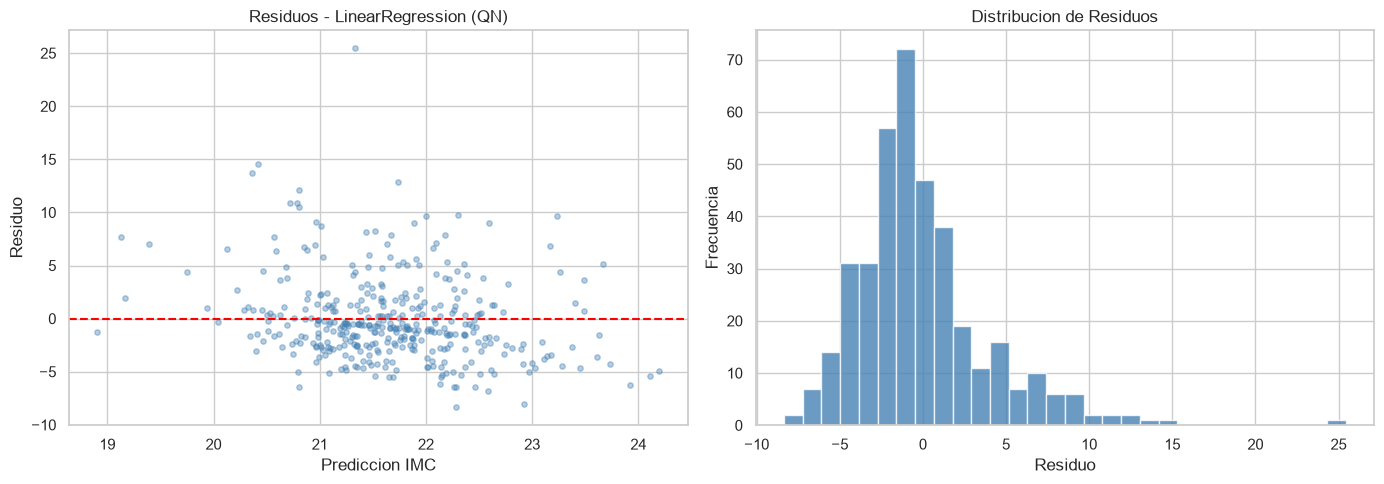

In [16]:
# Visualizacion de residuos del mejor modelo
best = rf_pipe if rf_metrics['rmse'] < lr_metrics['rmse'] else lr_pipe
best_name = 'RandomForest' if rf_metrics['rmse'] < lr_metrics['rmse'] else 'LinearRegression'
y_pred = best.predict(X_val[available])
residuals = y_reg_val.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Prediccion IMC')
axes[0].set_ylabel('Residuo')
axes[0].set_title(f'Residuos - {best_name} ({FEATURE_TYPE})')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de Residuos')
plt.tight_layout()
plt.show()

---
## 3. Prototipo Clasificacion (Riesgo Salud Mental)

Entrenamiento rapido de LogisticRegression, RandomForest y XGBoost con manejo de desbalance.

In [17]:
n_neg = int((y_clf_train == 0).sum())
n_pos = int((y_clf_train == 1).sum())
spw = n_neg / n_pos
print(f'Distribucion train: Sin Riesgo={n_neg} | Con Riesgo={n_pos}')
print(f'scale_pos_weight = {spw:.2f}\n')

results = {}
for model_key, model_name in [('lr', 'LogisticRegression'), ('rf', 'RandomForest'), ('xgb', 'XGBoost')]:
    kwargs = {'feature_type': FEATURE_TYPE, 'model': model_key}
    if model_key == 'xgb':
        kwargs['scale_pos_weight'] = spw
    
    pipe = build_classification_pipeline(**kwargs)
    pipe.fit(X_train[available], y_clf_train)
    
    y_proba = pipe.predict_proba(X_val[available])[:, 1]
    threshold, f1_opt = find_optimal_threshold(y_clf_val, y_proba)
    metrics = evaluate_classification(pipe, X_val[available], y_clf_val, threshold)
    
    results[model_key] = {'name': model_name, 'metrics': metrics, 'threshold': threshold, 'pipe': pipe}
    print(f'{model_name:<25} F1={metrics["f1"]:.4f}  AUC={metrics["auc"]:.4f}  Umbral={threshold:.4f}')

Distribucion train: Sin Riesgo=1182 | Con Riesgo=158
scale_pos_weight = 7.48

LogisticRegression        F1=0.6420  AUC=0.9153  Umbral=0.8151
RandomForest              F1=0.6667  AUC=0.9487  Umbral=0.4900
XGBoost                   F1=0.6420  AUC=0.9067  Umbral=0.6530


---
## 4. Comparativa Q vs QN

Entrena el mismo modelo (RandomForest) con ambos conjuntos de features para comparar el impacto.

In [18]:
from sklearn.model_selection import train_test_split
from src.data.cleaner import load_and_clean_survey, engineer_targets, RANDOM_STATE

# Cargar dataset completo (contiene tanto Q como QN)
df_full = load_and_clean_survey('../data/raw/SLV2013_Public_Use.csv')
df_full = engineer_targets(df_full)

comparison = []
for ft in ['Q', 'QN']:
    cols = get_feature_cols(ft)
    avail = [c for c in cols if c in df_full.columns]
    
    X_all = df_full[avail].copy()
    y_reg_all = df_full['IMC'].copy()
    y_clf_all = df_full['Riesgo_Salud_Mental'].copy()
    
    # Misma particion que el pipeline principal
    X_tr, X_tmp, yr_tr, yr_tmp, yc_tr, yc_tmp = train_test_split(
        X_all, y_reg_all, y_clf_all, test_size=0.30, random_state=RANDOM_STATE)
    X_vl, _, yr_vl, _, yc_vl, _ = train_test_split(
        X_tmp, yr_tmp, yc_tmp, test_size=1/3, random_state=RANDOM_STATE)
    
    # Imputar target IMC (fit solo en train)
    from sklearn.impute import SimpleImputer
    imp = SimpleImputer(strategy='median')
    yr_tr = pd.Series(imp.fit_transform(yr_tr.values.reshape(-1,1)).flatten(), index=yr_tr.index)
    yr_vl = pd.Series(imp.transform(yr_vl.values.reshape(-1,1)).flatten(), index=yr_vl.index)
    
    # Regresion
    pipe_reg = build_regression_pipeline(feature_type=ft, model='rf')
    pipe_reg.fit(X_tr, yr_tr)
    reg_m = evaluate_regression(pipe_reg, X_vl, yr_vl)
    
    # Clasificacion
    pipe_clf = build_classification_pipeline(feature_type=ft, model='rf')
    pipe_clf.fit(X_tr, yc_tr)
    y_prob = pipe_clf.predict_proba(X_vl)[:, 1]
    thr, _ = find_optimal_threshold(yc_vl, y_prob)
    clf_m = evaluate_classification(pipe_clf, X_vl, yc_vl, thr)
    
    comparison.append({
        'Features': ft,
        'N_cols': len(avail),
        'RMSE': round(reg_m['rmse'], 4),
        'R2': round(reg_m['r2'], 4),
        'F1': round(clf_m['f1'], 4),
        'AUC': round(clf_m['auc'], 4),
    })

df_comp = pd.DataFrame(comparison)
print('Comparativa RandomForest: Q vs QN (validacion)')
print(df_comp.to_string(index=False))

Cargado: 1915 filas x 104 columnas

IMC calculado: 1738 valores validos

Riesgo: Sin Riesgo=1703 | Con Riesgo=212

Comparativa RandomForest: Q vs QN (validacion)
Features  N_cols   RMSE      R2     F1    AUC
       Q      46 4.0145 -0.0629 0.6512 0.9366
      QN      43 4.0590 -0.0866 0.6667 0.9487


---
## 5. Analisis de Umbral Optimo

Visualizacion de como varia el F1-Score, Precision y Recall al mover el umbral de decision.

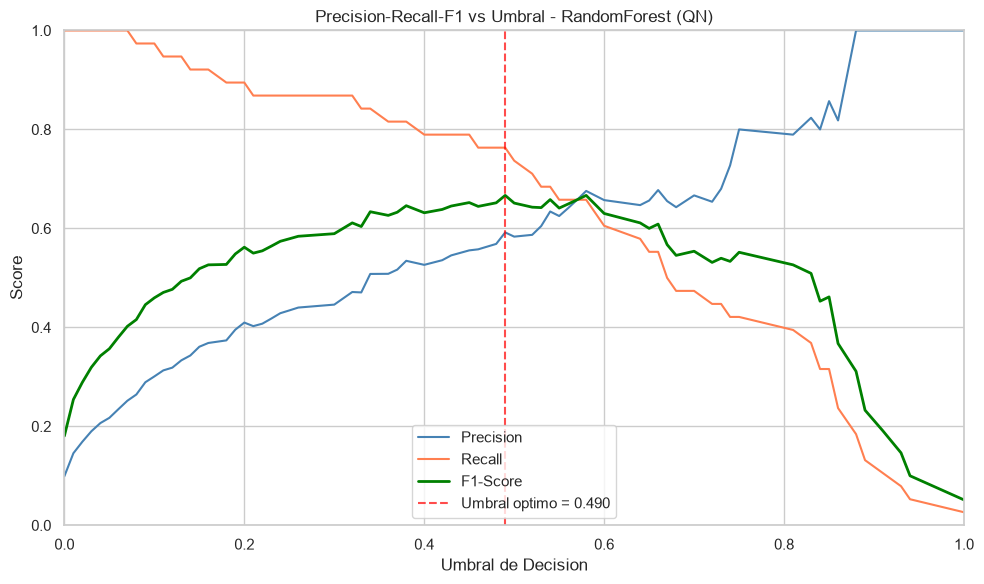

Umbral optimo: 0.4900 -> F1=0.6667


In [19]:
from sklearn.metrics import precision_recall_curve, f1_score

# Usar el mejor modelo de clasificacion
best_key = max(results, key=lambda k: results[k]['metrics']['f1'])
best_clf = results[best_key]
y_proba = best_clf['pipe'].predict_proba(X_val[available])[:, 1]

precision, recall, thresholds = precision_recall_curve(y_clf_val, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recall[:-1], label='Recall', color='coral')
ax.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=2)

opt_idx = np.argmax(f1_scores)
opt_thr = thresholds[opt_idx]
ax.axvline(x=opt_thr, color='red', linestyle='--', alpha=0.7,
           label=f'Umbral optimo = {opt_thr:.3f}')

ax.set_xlabel('Umbral de Decision')
ax.set_ylabel('Score')
ax.set_title(f'Precision-Recall-F1 vs Umbral - {best_clf["name"]} ({FEATURE_TYPE})')
ax.legend(loc='best')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Umbral optimo: {opt_thr:.4f} -> F1={f1_scores[opt_idx]:.4f}')

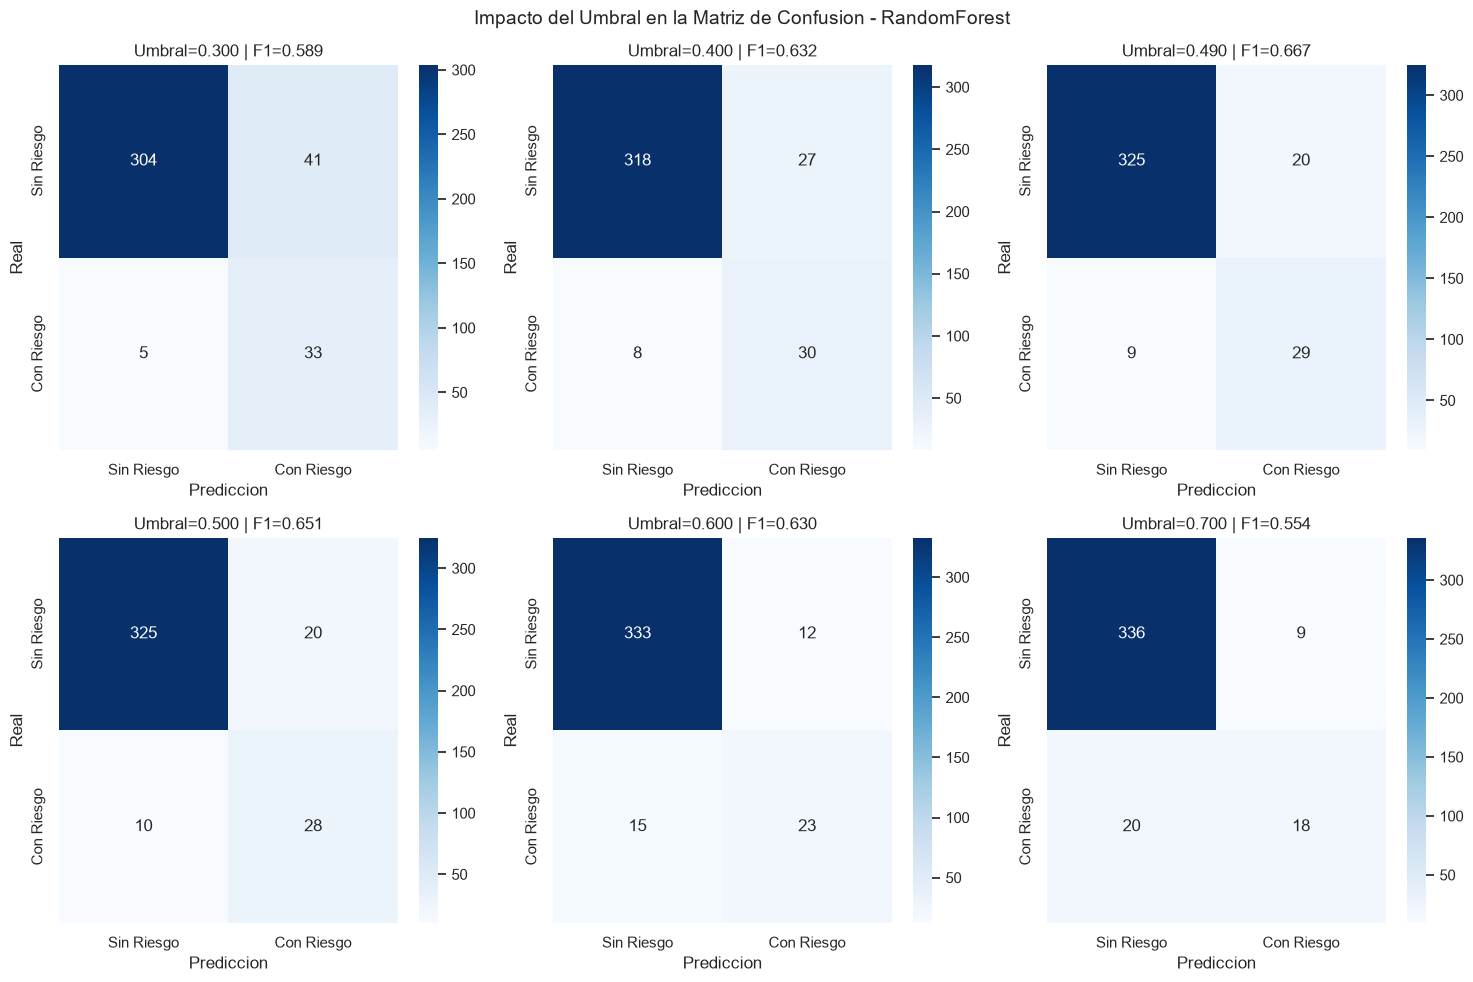

In [20]:
from sklearn.metrics import confusion_matrix

# Impacto del umbral en la matriz de confusion
thresholds_to_test = [0.3, 0.4, opt_thr, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, thr in zip(axes.flatten(), thresholds_to_test):
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_clf_val, y_pred)
    f1 = f1_score(y_clf_val, y_pred, zero_division=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin Riesgo', 'Con Riesgo'],
                yticklabels=['Sin Riesgo', 'Con Riesgo'])
    ax.set_title(f'Umbral={thr:.3f} | F1={f1:.3f}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.suptitle(f'Impacto del Umbral en la Matriz de Confusion - {best_clf["name"]}', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Feature Importance del Mejor Clasificador

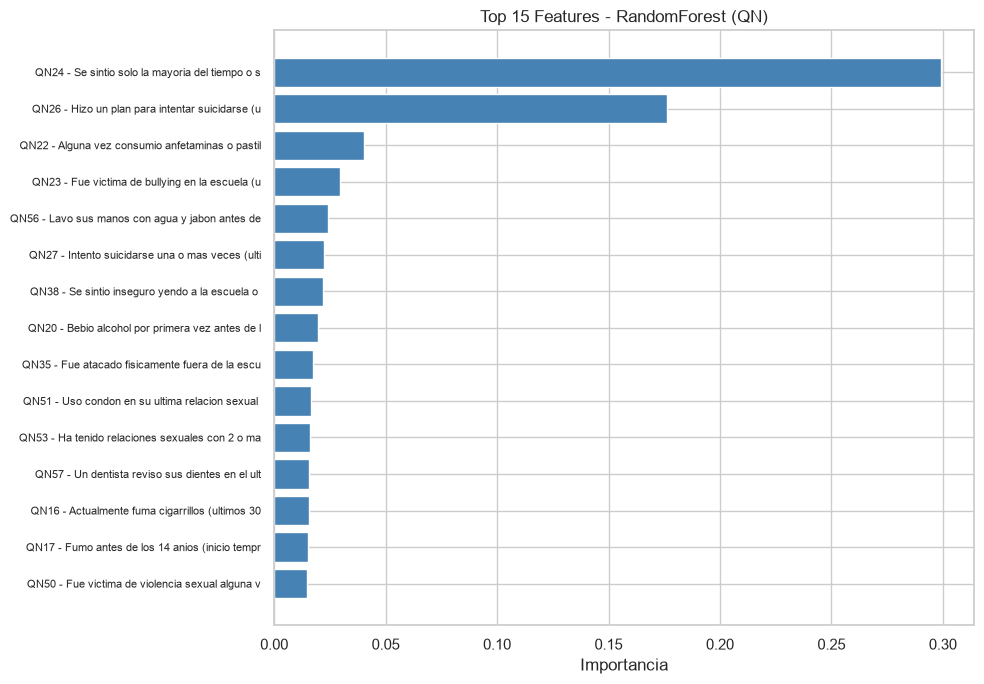

In [21]:
# Extraer el estimador final del pipeline
clf_estimator = best_clf['pipe'].named_steps.get('classifier', best_clf['pipe'])

if hasattr(clf_estimator, 'feature_importances_'):
    importances = clf_estimator.feature_importances_
    readable = feature_names_readable(available, '../data/codebook.json')
    
    n = min(len(importances), len(available))
    indices = np.argsort(importances[:n])[-15:]
    top_labels = [f'{available[i]} - {readable[i][:40]}' for i in indices]
    top_vals = importances[indices]
    
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(top_labels)), top_vals, color='steelblue')
    ax.set_yticks(range(len(top_labels)))
    ax.set_yticklabels(top_labels, fontsize=8)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 15 Features - {best_clf["name"]} ({FEATURE_TYPE})')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_clf["name"]} no soporta feature_importances_ directamente.')